<a href="https://colab.research.google.com/github/ja2faded/A04-clustering/blob/main/A4jacksongayeskinotebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Assignment: $k$ Means Clustering


**Q1.** This is a question about clustering. We want to investigate how adjusting the "noisiness" of the data impacts the quality of the algorithm and the difficulty of picking $k$.

1. Run the code below, which creates four datasets: `df0_125`, `df0_25`, `df0_5`, `df1_0`, and `df2_0`. Each data set is created by increasing the amount of `noise` (standard deviation) around the cluster centers, from `0.125` to `0.25` to `0.5` to `1.0` to `2.0`.

```
import numpy as np
import pandas as pd

def createData(noise,N=50):
    np.random.seed(100) # Set the seed for replicability
    # Generate (x1,x2,g) triples:
    X1 = np.array([np.random.normal(1,noise,N),np.random.normal(1,noise,N)])
    X2 = np.array([np.random.normal(3,noise,N),np.random.normal(2,noise,N)])
    X3 = np.array([np.random.normal(5,noise,N),np.random.normal(3,noise,N)])
    # Concatenate into one data frame
    gdf1 = pd.DataFrame({'x1':X1[0,:],'x2':X1[1,:],'group':'a'})
    gdf2 = pd.DataFrame({'x1':X2[0,:],'x2':X2[1,:],'group':'b'})
    gdf3 = pd.DataFrame({'x1':X3[0,:],'x2':X3[1,:],'group':'c'})
    df = pd.concat([gdf1,gdf2,gdf3],axis=0)
    return df

df0_125 = createData(0.125)
df0_25 = createData(0.25)
df0_5 = createData(0.5)
df1_0 = createData(1.0)
df2_0 = createData(2.0)
```

2. Make scatterplots of the $(X1,X2)$ points by group for each of the datasets. As the `noise` goes up from 0.125 to 2.0, what happens to the visual distinctness of the clusters?
3. Create a scree plot for each of the datasets. Describe how the level of `noise` affects the scree plot (particularly the presence of a clear "elbow") and your ability to definitively select a $k$. (Pay attention to the vertical axis across plots, or put all the scree curves on a single canvas.)
4. Explain the intuition of the elbow, using this numerical simulation as an example.

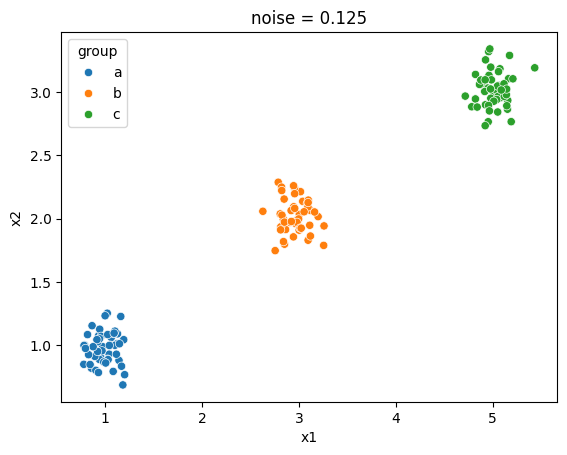

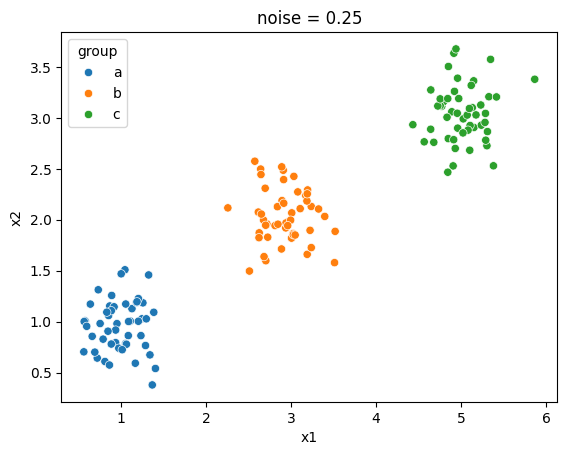

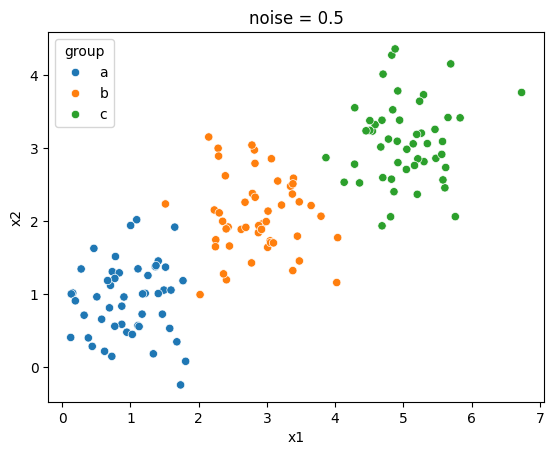

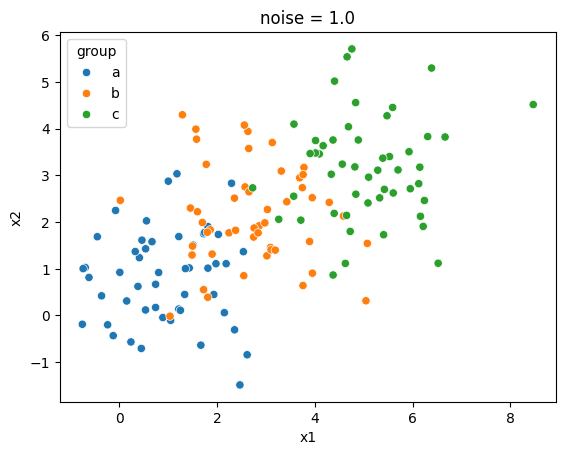

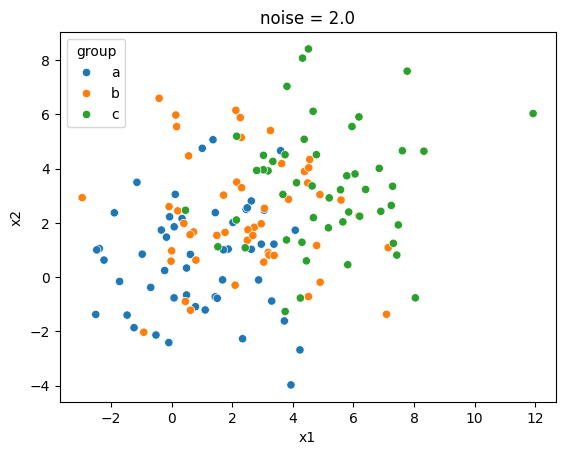

<Figure size 640x480 with 0 Axes>

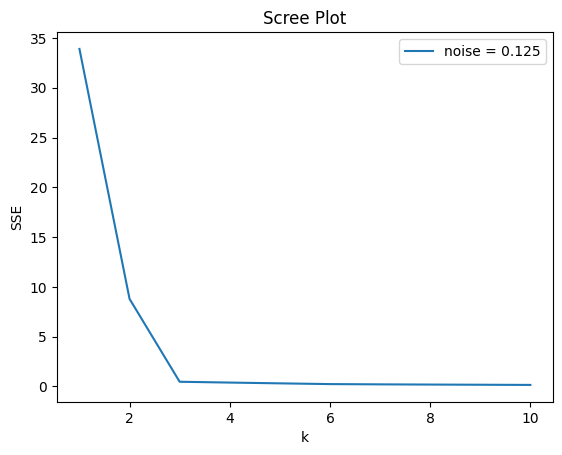

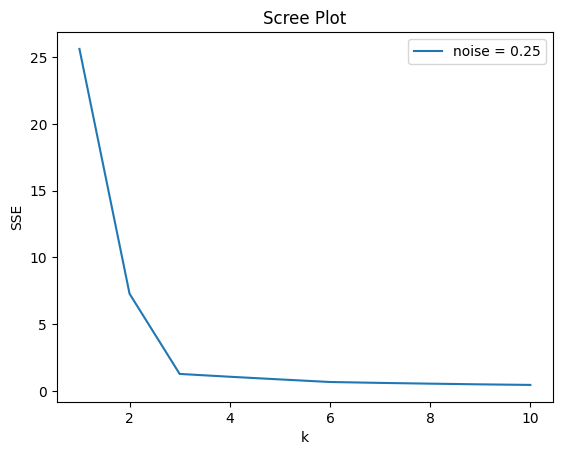

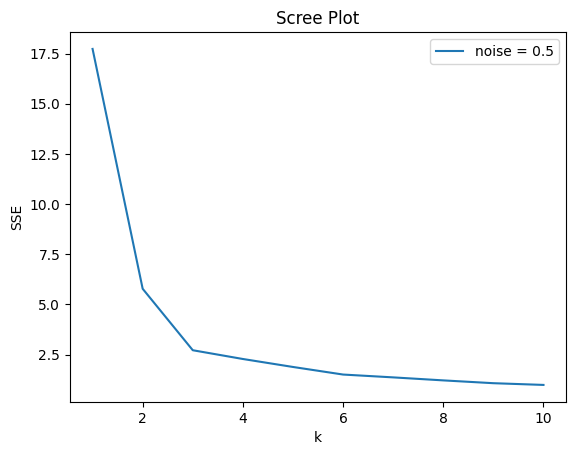

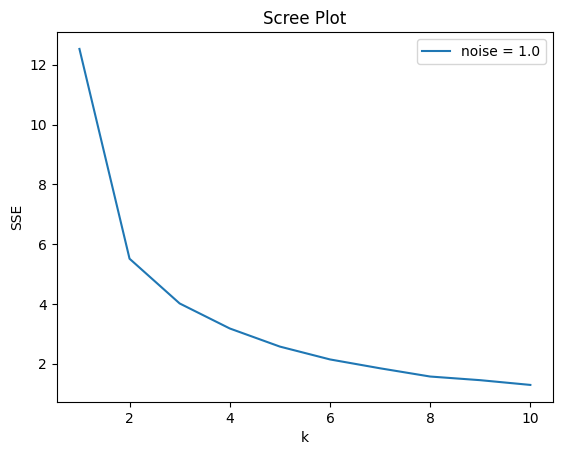

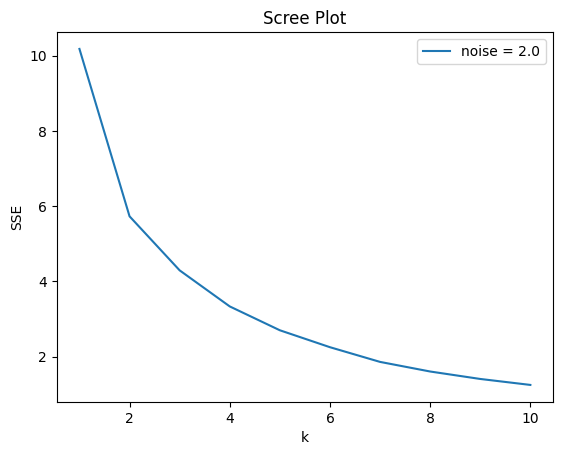

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def createData(noise,N=50):
    np.random.seed(100) # Set the seed for replicability
    # Generate (x1,x2,g) triples:
    X1 = np.array([np.random.normal(1,noise,N),np.random.normal(1,noise,N)])
    X2 = np.array([np.random.normal(3,noise,N),np.random.normal(2,noise,N)])
    X3 = np.array([np.random.normal(5,noise,N),np.random.normal(3,noise,N)])
    # Concatenate into one data frame
    gdf1 = pd.DataFrame({'x1':X1[0,:],'x2':X1[1,:],'group':'a'})
    gdf2 = pd.DataFrame({'x1':X2[0,:],'x2':X2[1,:],'group':'b'})
    gdf3 = pd.DataFrame({'x1':X3[0,:],'x2':X3[1,:],'group':'c'})
    df = pd.concat([gdf1,gdf2,gdf3],axis=0)
    return df

df0_125 = createData(0.125)
df0_25 = createData(0.25)
df0_5 = createData(0.5)
df1_0 = createData(1.0)
df2_0 = createData(2.0)


#2 Scatterplots
datasets = {'0.125': df0_125, '0.25': df0_25, '0.5': df0_5, '1.0': df1_0, '2.0': df2_0}

for noise in datasets:
    plt.figure()
    sns.scatterplot(data=datasets[noise], x='x1', y='x2', hue = 'group').set(title=f"noise = {noise}")

plt.figure()

#as the noise goes up from .125 to 2.0, the visual distinctiveness of the clusters decreases
#At .125 there are clear distinct clusters; at .25 and .5 the clusters are still visible
#at 1.0 and 2.0 there are no obvious visually disctinct clusters.


#3 Scree Plot

from sklearn.cluster import KMeans

ks = np.arange(1, 11)

for noise in datasets:
  df=datasets[noise]
  features = ['x1', 'x2']
  unscaled = df[features]
  mins = unscaled.min()
  maxs = unscaled.max()
  ranges = maxs- mins
  x = (unscaled - mins)/ ranges

  SSE = [
      KMeans(n_clusters=k, max_iter=300, n_init=10, random_state=100)
      .fit(x).inertia_

      for k in ks

  ]

#individual Scree plots
  plt.figure()
  plt.plot(ks, SSE, label=f'noise = {noise}')
  plt.title("Scree Plot")
  plt.xlabel("k")
  plt.ylabel("SSE")
  plt.legend()
  plt.show()

#across plots, it appears that as the noise increases, the elbow at k = 3 begins to disappear
#at low noise (.125 and .25) the eblow at k =3 is very clear and there is no clear elbow at 1.0 and 2.0
#a less clear elbow (less of a drop in SSE) makes selecting the best value of k more difficult
#It also appears that higher noise starts with a lower SSE (at k=1) as seen by the vertical axis\



#4: Intuition of the elbow
#Increasing k generally reduces SSE, so finding the point where an increase of 1 in k causes a larger decrease
#in SSE (aka the elbow) is the best option for k
#As seen by the first set of graphs, there is clearly 3 groups. When k is smaller than the number of groups, KMean
#must cluster 2 groups into one. As a result, the SSE is high. When k=the number of actual groups, the SSE drops signifigantly
#since each group is grouped on their own. Further increases of k clusters would only break up the existing 3 groups
#With more noise, the groups overlap, making separating groups more difficult and changing the k reduces the SSE less,
#since the noise makes it difficult to group correctly.






**Q2.** This question is a case study on clustering.

1. Load the `SIPRI Military Expenditure Database.csv` file in the `./data` folder. This has data about military spending by country. Filter the rows to select only the year 2020, and drop all rows with missing values. I ended up with 148 countries. Is any further cleaning of the variables required?
2. Max-min normalize `Spending (2020 USD)` and `Spending per Capita`. Use a scree plot to determine the optimal number of clusters for the $k$ means clustering algorithm. Make a scatter plot of `Spending (2020 USD)` and `Spending per Capita`, and hue the dots by their cluster membership. Compute a describe table conditional on cluster membership (i.e. `.groupby(cluster).describe()`). What do you see? Where is the United States? Do you notice any patterns in the cluster membership?
3. Repeat part 2 for `Percent of Government Spending` and `Percent of GDP`. How do your results compare to part 2?
4. Use $k$ means clustering with all four numeric variables: `Spending (2020 USD)`, `Spending per Capita`, `Percent of Government Spending`, and `Percent of GDP`. How do your results compare to the previous two parts?
5. Did the $k$-MC algorithm find any useful patterns for you in analyzing the spending?

Mounted at /content/drive
(148, 7)
index                               int64
Year                                int64
Country                            object
Spending (2020 USD)               float64
Percent of GDP                    float64
Percent of Government Spending    float64
Spending per Capita               float64
dtype: object
             index    Year  Spending (2020 USD)  Percent of GDP  \
count   148.000000   148.0           148.000000      148.000000   
mean   2831.256757  2020.0         13153.747670        0.019619   
std    1654.299355     0.0         68005.236120        0.015033   
min      32.000000  2020.0             8.622460        0.000054   
25%    1409.000000  2020.0           204.877177        0.010413   
50%    2871.000000  2020.0           959.535443        0.015324   
75%    4222.500000  2020.0          5289.998320        0.024327   
max    5880.000000  2020.0        778397.200000        0.098470   

       Percent of Government Spending  Spending per C

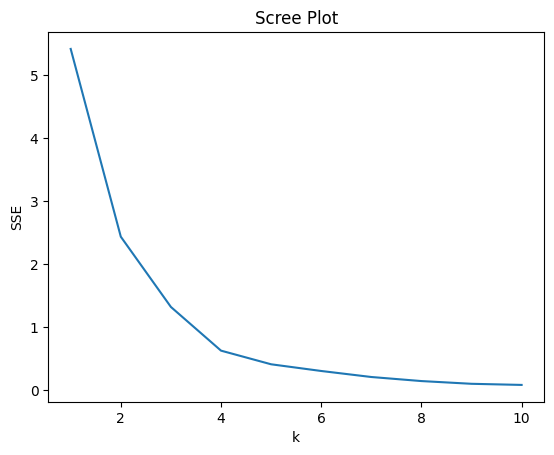

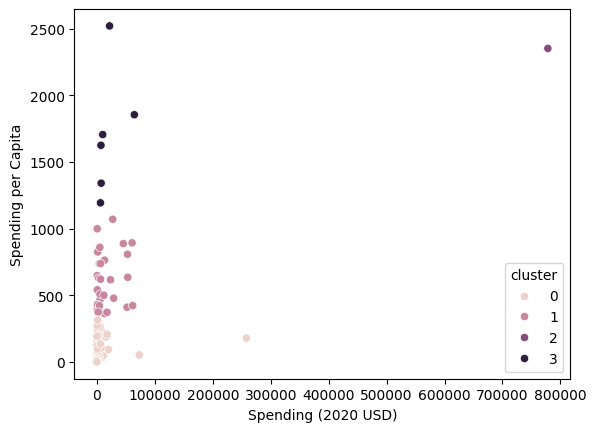

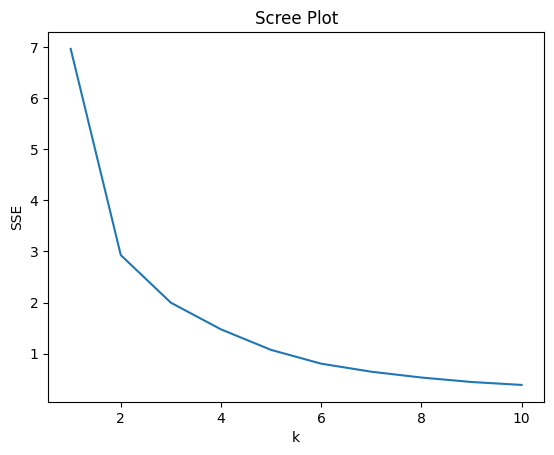

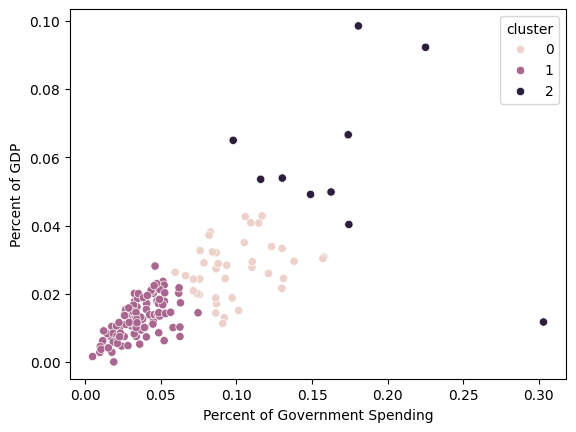

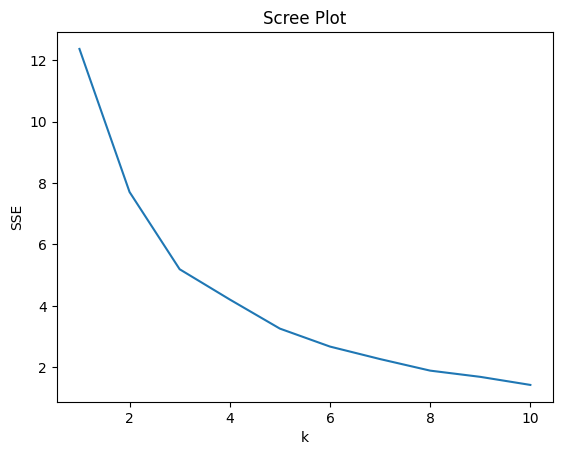

<Figure size 640x480 with 0 Axes>

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
drive.mount ('/content/drive')


df = pd.read_csv('/content/drive/MyDrive/SIPRI Military Expenditure Database.csv')

#1 cleaning
#filter by year (2020)
df = df.loc[df['Year'] == 2020].dropna()

print(df.shape)
print(df.dtypes)
print(df.describe())

#no further cleaning is necessary:
#the 4 money/ percent variables are already floats; country is okay as an object; year is irrelavant (only 2020)
#shape matches the 148 in the question


#2 minmax normalize


#scree plot
from sklearn.cluster import KMeans
features = ["Spending (2020 USD)", "Spending per Capita"]
unscaled = df[features]
mins = unscaled.min()
maxs = unscaled.max()
ranges = maxs- mins
x = (unscaled - mins)/ ranges

ks = np.arange(1,11)

SSE = [
      KMeans(n_clusters=k, max_iter=300, n_init=10, random_state=100)
      .fit(x).inertia_

      for k in ks
  ]
sns.lineplot(x=ks, y=SSE).set(title="Scree Plot", xlabel = "k", ylabel="SSE")
plt.figure()

#elbow at k =4

#scatterplot
model = KMeans(n_clusters=4, max_iter=300, n_init=10, random_state=100).fit(x)
df["cluster"] = model.labels_
sns.scatterplot(data=df, x = "Spending (2020 USD)", y = "Spending per Capita", hue = 'cluster')

#describe table
print(df[features + ["cluster"]].groupby("cluster").describe())

plt.figure()

for country in sorted(df["cluster"].unique()):
  print(country, df.loc[df["cluster"] == country, "Country"].tolist())

#there is a clear elbow (drop off in SSE)at k = 4
#the 4 clusters are mostly separated based on spending per capita, as seen in the scatterplot (no clear grouping across x except for US)
#the US is alone in cluster 2 (why the SD is NaN) and is by far the highest spender overall
# cluster 3 has 6 countries and the highest spending per capita
# cluster 0 has 111 countries and cluster 1 has 30 countries; both spend less per capita than the other two groups
#4/6 of cluster 3's countries are in the middle east




#3 Repeat 2 with Percent of Government Spending and Percent of GDP

#scree
features = ["Percent of Government Spending", "Percent of GDP"]
unscaled = df[features]
mins = unscaled.min()
maxs = unscaled.max()
ranges = maxs- mins
x = (unscaled - mins)/ ranges

ks = np.arange(1,11)

SSE = [
      KMeans(n_clusters=k, max_iter=300, n_init=10, random_state=100)
      .fit(x).inertia_

      for k in ks
  ]
sns.lineplot(x=ks, y=SSE).set(title="Scree Plot", xlabel = "k", ylabel="SSE")
plt.figure()

#elbow at k = 3 (very faint)

#scatterplot
model = KMeans(n_clusters=3, max_iter=300, n_init=10, random_state=100).fit(x)
df["cluster"] = model.labels_
sns.scatterplot(data=df, x = "Percent of Government Spending", y = "Percent of GDP", hue = 'cluster')

#describe table
print(df[features + ["cluster"]].groupby("cluster").describe())

plt.figure()


for country in sorted(df["cluster"].unique()):
  print(country, df.loc[df["cluster"] == country, "Country"].tolist())

#the elbow is much less sharp than in part 2
#US no longer in its own cluster (now in cluster 0); each cluster has multiple countries
#the clusters for part 2 were largely driven by the y; here is seems more even (x and y influence)
#It makes sense that more war torn countries (Isreal, Pakistan) are in the highest cluster

#4: KMeans clustering with 4 numeric variables

#scree
features = ["Spending (2020 USD)", "Spending per Capita", "Percent of Government Spending", "Percent of GDP"]
unscaled = df[features]
mins = unscaled.min()
maxs = unscaled.max()
ranges = maxs- mins
x = (unscaled - mins)/ ranges

ks = np.arange(1,11)

SSE = [
      KMeans(n_clusters= k, max_iter=300, n_init=10, random_state=100)
      .fit(x).inertia_

      for k in ks
  ]
sns.lineplot(x=ks, y=SSE).set(title="Scree Plot", xlabel = "k", ylabel="SSE")
plt.figure()

#no clear elbow: SSE keeps dropping by similar amounts; set k = 4

model = KMeans(n_clusters=4, max_iter=300, n_init=10, random_state=100).fit(x)
df["cluster"] = model.labels_

#describe table
print(df[features + ["cluster"]].groupby("cluster").describe())


for country in sorted(df["cluster"].unique()):
  print(country, df.loc[df["cluster"] == country, "Country"].tolist())

#the clusters combine both wealth/ spending per capital and the millitary spending of the country
#Unlike part 2, the US is not in its own group
#the 4 variables makes it difficult to see a true elbow, therefore selecting k is essentially arbitrary
#it appears the 4 groups are roughly: wealthy countries  + a lot of military spending, wealthy countries with little military spending,
#poor countries with a lot of military spending, poor countries with no military spending; this is a great simplification


#5
#KMeans showed to be useful for groupings like poor vs rich in part 2 and high vs low military burden in part 3, but once you start introducing
#more than 2 variables (like in part 4), this approach becomes less useful, as the clustering becomes more difficult
#additionally, the clustering depends greatly on what variables are used
#additionally, throughout this anaylsis, it appears that most countries get grouped into a large lower cluster












## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Jackson Gayeski

**Date:** 10/8/26

In [3]:
# Your Phase 1 solution to the problem goes here.


## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:**=
7171e6f

- **AI tool and model used:** Opus 5.5

### *Prompts used

1. given my code for part 1 of my assignment, improve the presentation of information in the graphs and tables. Specifically, make the tables more informative and specific. Compile the graphs of the scree plot in one with an intuitive legend.
2. additionally, change the comments on the data analysis to highlight contextual information I may have missed. Do not alter original comments, but do indicate what you added.
3. given my code for part 2 of my assignment, improve the presentation of information in the graphs and tables. Specifically, make the tables more informative and specific. Compile the graphs of the scree plot in one with an intuitive legend.
4. additionally, change the comments on the data analysis to highlight contextual information I may have missed. Do not alter original comments, but do indicate what you added.

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

Fixed the return df indentation bug in createData.
Added a table of group means and SDs by noise level, compared against the true centers.
Combined the five scatterplots into one figure with a shared legend and true-center markers.
Combined all scree plots into one figure: raw SSE and normalized SSE (relative to k=1), color-coded by noise, with a dashed line at true k=3.
Added tables of SSE by k and of % SSE reduction from k-1 to k, to quantify the elbow.
Added context: identical seeds make the noise levels a controlled comparison.
Added context: center separation relative to noise SD explains when clusters stop being distinguishable.
Added context: lower SSE at high noise is a min-max scaling artifact.
Added context: this data matches k-means assumptions (best case), and the elbow measures separability, not the true number of groups.

Part 2 (SIPRI military spending)

Replaced repeated code with helper functions (scaling, scree, cluster summary, member lists, scatterplots) without changing the KMeans results.
Saved each part's cluster labels in a separate column instead of overwriting them.
Added cleaning output: which countries were dropped, plus readable dtype and summary-stat tables.
Combined the scree plots for parts 2–4 into one figure (raw and normalized) with the chosen k circled.
Added scree tables (SSE and % drop) for each part.
Added cleaner cluster profile tables: n, mean, median, SD, and top 3 countries.
Added labeled scatterplots, including a log-scale view for part 2.
Added a correlation table for parts 3 and 4, and a cross-tab showing how countries move between part 2 and part 3 clusters.
Added a pairplot to visualize the 4-variable clusters in part 4.
Added context: 2020 COVID effects, market exchange rates vs PPP, and possible bias from dropped countries.
Added context: the US outlier compresses total spending under min-max scaling and claims its own cluster.
Added context: correlated burden measures form a continuum, explaining the faint elbow and the double-weighting in part 4.
Added context: per capita spending mixes wealth and military priority, and high burden is not the same as active war.
Suggested alternatives: log or z-score scaling and silhouette scores.

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept | the revisions made the information more visually appealing and easier to comprehend. I compared with my original findings, and they matched. Although I did not ask to fix the indentation bug, it did anyways and I verified this by checking against my original code. I also checked the added context by using google. |
| 2 | Accept  | the added comments make understanding the actual findings easier and help strengthen the findings. I also verified this with google and took a minute to read through and see if it made sense.|
| 3 | Accept: Like the first prompt, this allowed for a more appealing presentation of the information. The graphs and tables are now much easier to understand in comparison to my original output. Using the helper functions also improved my code signifigantly in its flow. I verified the changes by reviewing the code.  
|4|  Like the second prompt, it uncovered context dependent information about the countries and the related graphs , such as rivalries in the countries that may contribute to the military spending. I verified the outside information using my current knowledge of geography and google.

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

Table 1. Group means and standard deviations by noise level
(true centers: a = (1,1), b = (3,2), c = (5,3); true SD = noise)


x1            x2       
              mean    std   mean    std
noise group                            
0.125 a      0.995  0.119  0.979  0.125
      b      2.965  0.133  2.018  0.130
      c      5.008  0.130  3.020  0.137
0.250 a      0.990  0.238  0.958  0.251
      b      2.929  0.266  2.036  0.261
      c      5.015  0.260  3.039  0.274
0.500 a      0.980  0.475  0.916  0.502
      b      2.859  0.532  2.071  0.521
      c      5.031  0.520  3.078  0.549
1.000 a      0.959  0.951  0.832  1.004
      b      2.717  1.064  2.142  1.042
      c      5.061  1.040  3.156  1.098
2.000 a      0.918  1.902  0.665  2.007
      b      2.435  2.129  2.284  2.084
      c      5.122  2.081  3.313  2.196

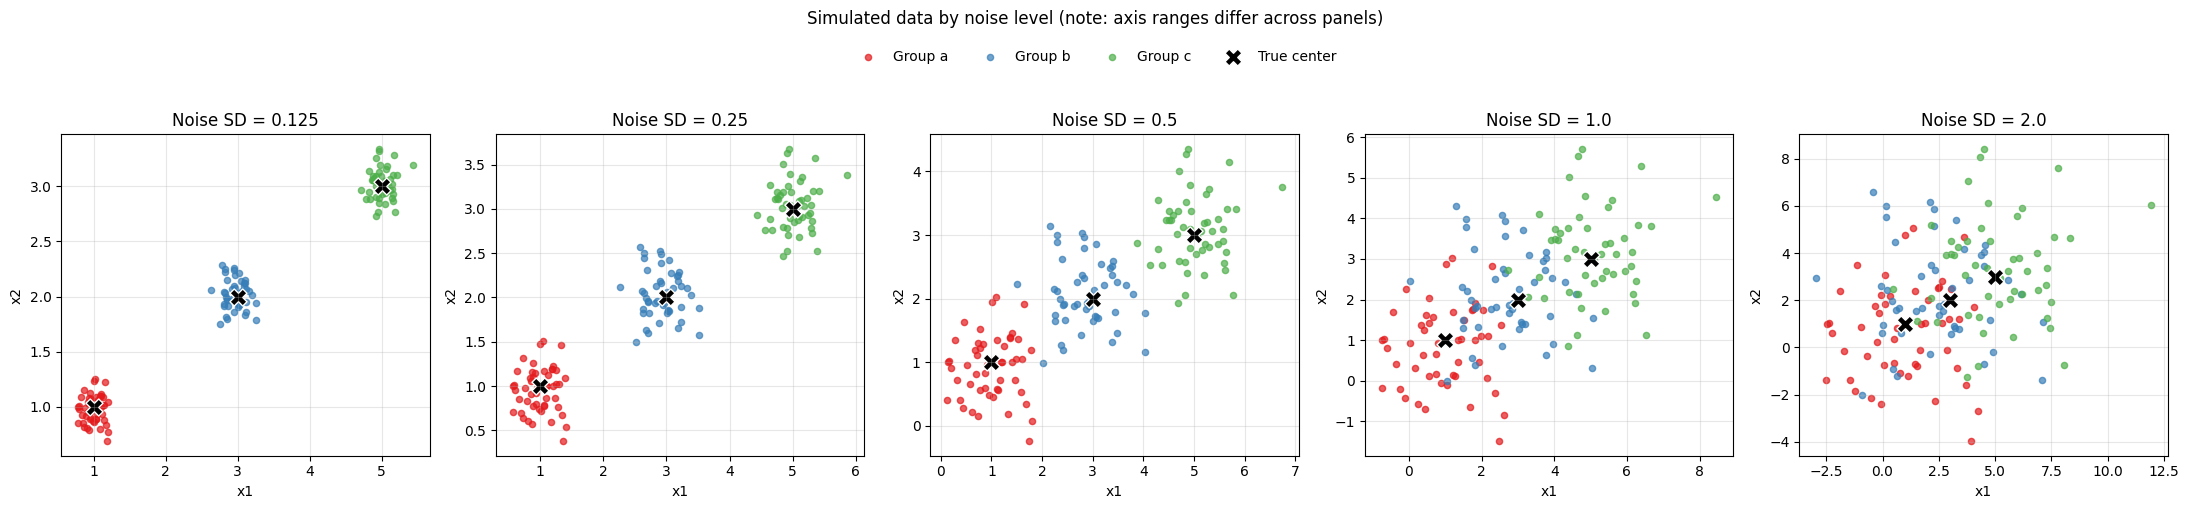

Table 2. Within-cluster SSE by k and noise level (min-max scaled features)


noise SD,0.125,0.250,0.500,1.000,2.000
k,,,,,
1,33.904,25.627,17.735,12.529,10.180
2,8.795,7.277,5.779,5.510,5.731
3,0.470,1.268,2.715,4.014,4.296
4,0.388,1.056,2.279,3.177,3.337
5,0.310,0.857,1.881,2.571,2.704
6,0.235,0.662,1.503,2.141,2.254
7,0.208,0.595,1.362,1.844,1.863
8,0.188,0.538,1.212,1.569,1.608
9,0.170,0.485,1.072,1.447,1.410


Table 3. % reduction in SSE when going from k-1 to k clusters
(a large value at k = 3 followed by small values = a clear elbow)


noise SD,0.125,0.250,0.500,1.000,2.000
k,,,,,
2,74.1,71.6,67.4,56.0,43.7
3,94.7,82.6,53.0,27.2,25.1
4,17.5,16.7,16.1,20.9,22.3
5,20.1,18.9,17.4,19.1,19.0
6,24.1,22.7,20.1,16.7,16.6
7,11.4,10.1,9.4,13.9,17.3
8,9.7,9.6,11.0,14.9,13.7
9,9.5,9.8,11.5,7.8,12.3
10,10.9,8.7,8.0,11.0,11.2


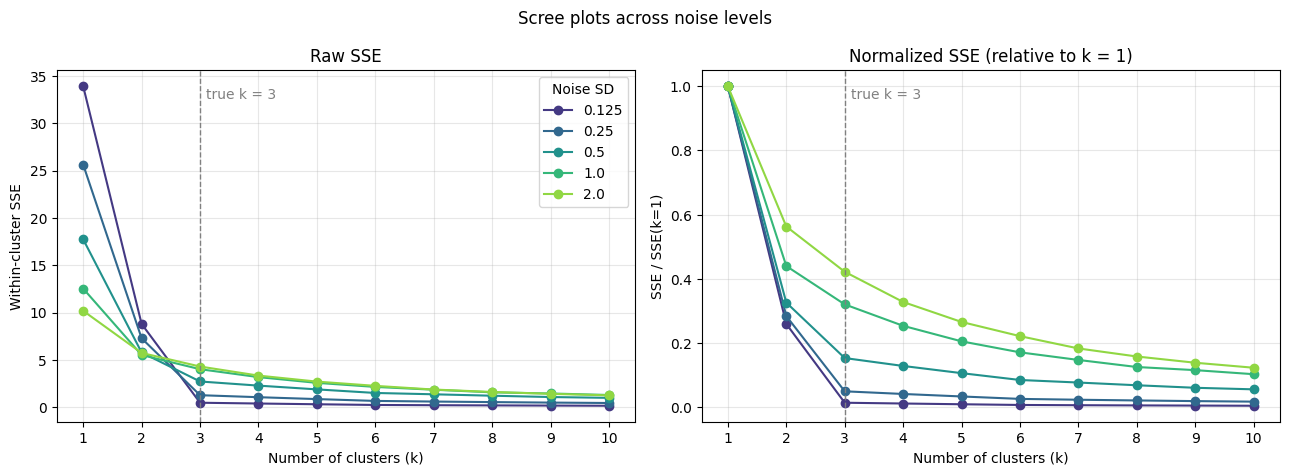

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from IPython.display import display

# ---------------------------------------------------------------
# 1. Data generation
# ---------------------------------------------------------------
def createData(noise, N=50):
    np.random.seed(100) # Set the seed for replicability
# Generate (x1,x2,g) triples:
    X1 = np.array([np.random.normal(1, noise, N), np.random.normal(1, noise, N)])
    X2 = np.array([np.random.normal(3, noise, N), np.random.normal(2, noise, N)])
    X3 = np.array([np.random.normal(5, noise, N), np.random.normal(3, noise, N)])
# Concatenate into one data frame
    gdf1 = pd.DataFrame({'x1': X1[0, :], 'x2': X1[1, :], 'group': 'a'})
    gdf2 = pd.DataFrame({'x1': X2[0, :], 'x2': X2[1, :], 'group': 'b'})
    gdf3 = pd.DataFrame({'x1': X3[0, :], 'x2': X3[1, :], 'group': 'c'})
    df = pd.concat([gdf1, gdf2, gdf3], axis=0)
    return df  # moved inside the function (was dedented in original -> error)

noise_levels = [0.125, 0.25, 0.5, 1.0, 2.0]
datasets = {n: createData(n) for n in noise_levels}

# True cluster centers used to generate the data
true_centers = pd.DataFrame({'x1': [1, 3, 5], 'x2': [1, 2, 3]},
                            index=pd.Index(['a', 'b', 'c'], name='group'))

# Table 1: sample mean and SD of each group at each noise level
summary = (pd.concat(datasets, names=['noise'])
             .groupby(['noise', 'group'])[['x1', 'x2']]
             .agg(['mean', 'std'])
             .round(3))
print("Table 1. Group means and standard deviations by noise level")
print("(true centers: a = (1,1), b = (3,2), c = (5,3); true SD = noise)")
display(summary)

# [ADDED] Because np.random.seed(100) is reset inside createData, every dataset uses the
# [ADDED] exact same underlying standard-normal draws, just multiplied by a different noise SD.
# [ADDED] So each dataset is the same point pattern stretched around the centers. Differences
# [ADDED] between noise levels come purely from noise magnitude, not random luck. This makes
# [ADDED] it a controlled comparison.


#2 Scatterplots
# ---------------------------------------------------------------
# 2. Scatterplots (one figure, one panel per noise level)
# ---------------------------------------------------------------
palette = dict(zip(['a', 'b', 'c'], sns.color_palette('Set1', 3)))

fig, axes = plt.subplots(1, len(noise_levels), figsize=(22, 4.5))
for ax, n in zip(axes, noise_levels):
    for g, sub in datasets[n].groupby('group'):
        ax.scatter(sub['x1'], sub['x2'], s=20, alpha=0.7,
                   color=palette[g], label=f'Group {g}')
    ax.scatter(true_centers['x1'], true_centers['x2'], marker='X', s=150,
               color='black', edgecolor='white', label='True center')
    ax.set_title(f'Noise SD = {n}')
    ax.set_xlabel('x1')
    ax.set_ylabel('x2')
    ax.grid(alpha=0.3)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=4, frameon=False,
           bbox_to_anchor=(0.5, 1.06))
fig.suptitle('Simulated data by noise level (note: axis ranges differ across panels)',
             y=1.12)
plt.tight_layout()
plt.show()

#as the noise goes up from .125 to 2.0, the visual distinctiveness of the clusters decreases
#At .125 there are clear distinct clusters; at .25 and .5 the clusters are still visible
#at 1.0 and 2.0 there are no obvious visually disctinct clusters.

# [ADDED] Whether clusters are distinguishable depends on center separation relative to noise.
# [ADDED] Adjacent centers (a-b, b-c) are sqrt(2^2 + 1^2) ~ 2.24 units apart, so separation/SD is:
# [ADDED]   0.125 -> ~18 SD,  0.25 -> ~9 SD,  0.5 -> ~4.5 SD,  1.0 -> ~2.2 SD,  2.0 -> ~1.1 SD
# [ADDED] At 1.0, roughly 13% of each group falls past the midpoint toward a neighboring center.
# [ADDED] At 2.0, this rises to roughly 29%, which explains why the visual separation breaks down there.
# [ADDED] The 3 groups still exist at every noise level; only their detectability changes.
# [ADDED] The axis ranges grow with noise, so the low-noise panels are "zoomed in" by comparison.


#3 Scree Plot
# ---------------------------------------------------------------
# 3. Scree plot (all noise levels on one figure)
# ---------------------------------------------------------------
features = ['x1', 'x2']
ks = np.arange(1, 11)

sse = {}
for n, df in datasets.items():
    X = df[features]
    X = (X - X.min()) / (X.max() - X.min())  # min-max scale
    sse[n] = [KMeans(n_clusters=k, max_iter=300, n_init=10, random_state=100)
              .fit(X).inertia_ for k in ks]

sse_df = pd.DataFrame(sse, index=pd.Index(ks, name='k'))
sse_df.columns.name = 'noise SD'
sse_norm = sse_df / sse_df.iloc[0]               # SSE as a fraction of SSE at k = 1
pct_drop = (-sse_df.pct_change() * 100).round(1)  # % reduction from k-1 to k

# Table 2: raw SSE
print("Table 2. Within-cluster SSE by k and noise level (min-max scaled features)")
display(sse_df.round(3))

# Table 3: % reduction in SSE from adding one more cluster
print("Table 3. % reduction in SSE when going from k-1 to k clusters")
print("(a large value at k = 3 followed by small values = a clear elbow)")
display(pct_drop.iloc[1:])

# Combined scree plot
colors = sns.color_palette('viridis', len(noise_levels))
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
for c, n in zip(colors, noise_levels):
    axes[0].plot(ks, sse_df[n], marker='o', color=c, label=f'{n}')
    axes[1].plot(ks, sse_norm[n], marker='o', color=c, label=f'{n}')

for ax in axes:
    ax.axvline(3, ls='--', color='gray', lw=1)
    ax.text(3.1, ax.get_ylim()[1] * 0.95, 'true k = 3', color='gray', va='top')
    ax.set_xticks(ks)
    ax.set_xlabel('Number of clusters (k)')
    ax.grid(alpha=0.3)

axes[0].set(title='Raw SSE', ylabel='Within-cluster SSE')
axes[1].set(title='Normalized SSE (relative to k = 1)', ylabel='SSE / SSE(k=1)')
axes[0].legend(title='Noise SD', loc='upper right')
fig.suptitle('Scree plots across noise levels')
plt.tight_layout()
plt.show()

#across plots, it appears that as the noise increases, the elbow at k = 3 begins to disappear
#at low noise (.125 and .25) the eblow at k =3 is very clear and there is no clear elbow at 1.0 and 2.0
#a less clear elbow (less of a drop in SSE) makes selecting the best value of k more difficult
#It also appears that higher noise starts with a lower SSE (at k=1) as seen by the vertical axis\

# [ADDED] The lower SSE at k=1 for high noise is mostly an artifact of min-max scaling, not a sign of
# [ADDED] tighter data. After scaling, every dataset fits in [0,1] x [0,1]. At low noise, the 3 tight
# [ADDED] clusters sit at the edges and middle of that box, giving a large spread around the overall mean.
# [ADDED] At high noise, a few extreme points set the min/max, so the bulk of the data gets squeezed
# [ADDED] toward the center, giving a smaller SSE. Raw SSE is therefore not comparable across noise
# [ADDED] levels. The normalized panel (SSE / SSE at k=1) is the fairer comparison of elbow shape.
# [ADDED] Min-max scaling also changes the geometry. The centers span 4 units in x1 but only 2 in x2,
# [ADDED] so at low noise scaling stretches x2 relative to x1. At high noise, the ranges are dominated
# [ADDED] by noise in both directions, so scaling distorts the shape less.
# [ADDED] Table 3 shows the elbow numerically. At low noise, the k=2->3 drop is large and later drops
# [ADDED] are small. At high noise, the drops shrink gradually with no sharp break, so choosing k
# [ADDED] by eye becomes subjective. Silhouette scores or the gap statistic are common, less
# [ADDED] subjective alternatives.


#4: Intuition of the elbow
#Increasing k generally reduces SSE, so finding the point where an increase of 1 in k causes a larger decrease
#in SSE (aka the elbow) is the best option for k
#As seen by the first set of graphs, there is clearly 3 groups. When k is smaller than the number of groups, KMean
#must cluster 2 groups into one. As a result, the SSE is high. When k=the number of actual groups, the SSE drops signifigantly
#since each group is grouped on their own. Further increases of k clusters would only break up the existing 3 groups
#With more noise, the groups overlap, making separating groups more difficult and changing the k reduces the SSE less,
#since the noise makes it difficult to group correctly.

# [ADDED] With the optimal clustering, SSE can only stay the same or go down as k increases. In the limit
# [ADDED] k = number of points, SSE = 0. So the minimum SSE is never the goal; the elbow marks
# [ADDED] diminishing returns.
# [ADDED] This simulation is close to a best-case scenario for KMeans and the elbow method. The groups
# [ADDED] are round (equal noise in x1 and x2), equal in size (N=50 each), and equal in variance, which
# [ADDED] is exactly what KMeans assumes. Real data with elongated, unequal, or differently sized clusters
# [ADDED] would make the elbow less reliable even at low noise.
# [ADDED] At high noise, the true structure (3 generating distributions) is still there, but the elbow
# [ADDED] can't detect it. The elbow measures how separable the groups are, not how many processes
# [ADDED] generated the data.


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Rows in 2020: 173 | kept after dropna: 148 | dropped: 25
Dropped for missing data: Costa Rica, Cote d'Ivoire, Cuba, Czechoslovakia, Djibouti, Eritrea, Eswatini, German Democratic Republic, Iceland, Korea, North, Laos, Libya, Panama, Qatar, Somalia, Syria, Turkmenistan, United Arab Emirates, USSR, Uzbekistan, Venezuela, Viet Nam, Yemen, Yemen, North, Yugoslavia

Table 1. Column types


,dtype
index,int64
Year,int64
Country,object
Spending (2020 USD),float64
Percent of GDP,float64
Percent of Government Spending,float64
Spending per Capita,float64


Table 2. Summary statistics, 2020 (one row per variable)


,count,mean,std,min,25%,50%,75%,max
index,148.000,"2,831.257","1,654.299",32.000,"1,409.000","2,871.000","4,222.500","5,880.000"
Year,148.000,"2,020.000",0.000,"2,020.000","2,020.000","2,020.000","2,020.000","2,020.000"
Spending (2020 USD),148.000,"13,153.748","68,005.236",8.622,204.877,959.535,"5,289.998","778,397.200"
Percent of GDP,148.000,0.020,0.015,0.000,0.010,0.015,0.024,0.098
Percent of Government Spending,148.000,0.062,0.046,0.005,0.031,0.047,0.085,0.303
Spending per Capita,148.000,268.264,430.435,0.580,20.553,81.507,326.268,"2,520.399"


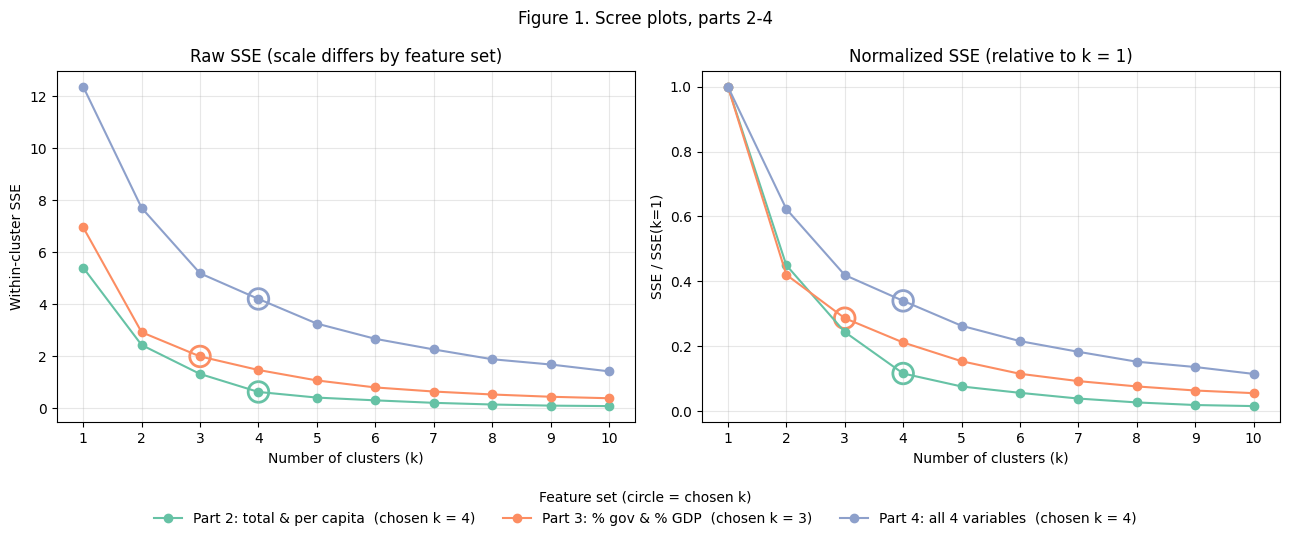

Table 3. Part 2 scree values


,SSE,% drop from k-1
k,,
1,5.411,NaN
2,2.435,54.998
3,1.322,45.722
4,0.629,52.382
5,0.413,34.364
6,0.307,25.698
7,0.212,31.070
8,0.147,30.460
9,0.104,29.416


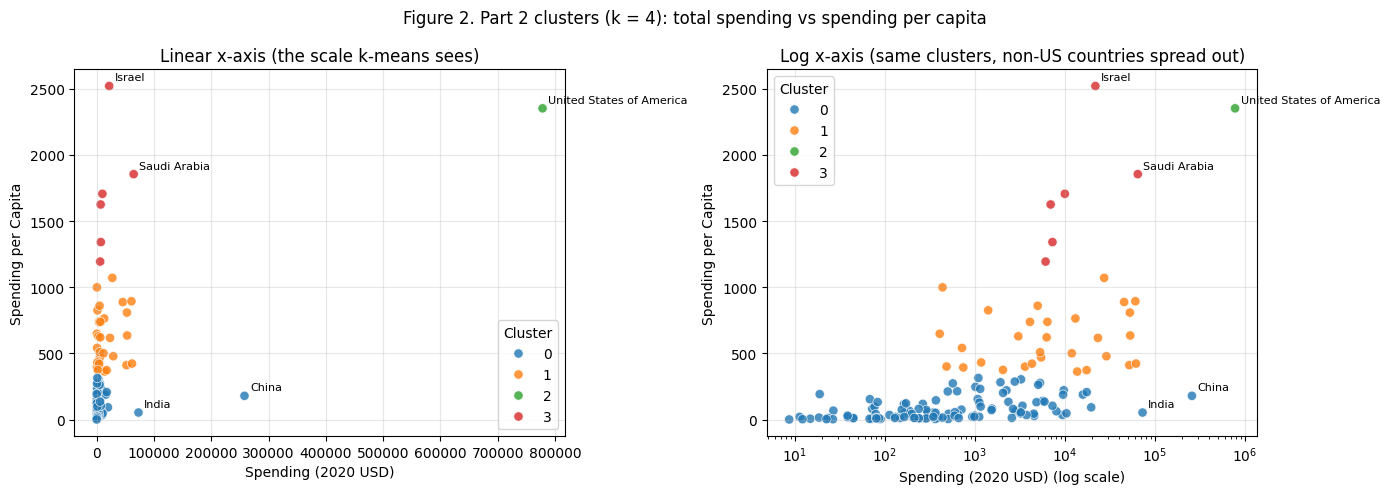

Table 4. Part 2 cluster profiles


n countries Spending (2020 USD)                         \
                                   mean      median        std   
cluster                                                          
0               111           4,859.185     382.465 25,405.739   
1                30          17,077.591   5,857.061 20,583.053   
2                 1         778,397.200 778,397.200        NaN   
3                 6          19,443.362   8,624.226 22,861.507   

        Spending per Capita                    \
                       mean    median     std   
cluster                                         
0                    80.061    47.057  83.502   
1                   607.479   579.005 206.929   
2                 2,351.632 2,351.632     NaN   
3                 1,706.722 1,665.447 466.376   

              top 3 by Spending per Capita  
                                            
cluster                                     
0                Uruguay, Czechia, Hungary  
1        Australia, Brunei, United Kingdom  
2                 United States of America  
3          Israel, Saudi Arabia, Singapore

Cluster 0 (111 countries): Afghanistan, Albania, Algeria, Angola, Argentina, Armenia, Azerbaijan, Bangladesh, Belarus, Belize, Benin, Bolivia, Bosnia and Herzegovina, Botswana, Brazil, Bulgaria, Burkina Faso, Burundi, Cambodia, Cameroon, Cape Verde, Central African Republic, Chad, Chile, China, Colombia, Congo, DR, Congo, Republic, Croatia, Czechia, Dominican Republic, Ecuador, Egypt, El Salvador, Equatorial Guinea, Ethiopia, Fiji, Gabon, Gambia, The, Georgia, Ghana, Guatemala, Guinea, Guinea-Bissau, Guyana, Haiti, Honduras, Hungary, India, Indonesia, Iran, Iraq, Ireland, Jamaica, Jordan, Kazakhstan, Kenya, Kosovo, Kyrgyz Republic, Lebanon, Lesotho, Liberia, Madagascar, Malawi, Malaysia, Mali, Malta, Mauritania, Mauritius, Mexico, Moldova, Mongolia, Montenegro, Morocco, Mozambique, Myanmar, Namibia, Nepal, Nicaragua, Niger, Nigeria, North Macedonia, Pakistan, Papua New Guinea, Paraguay, Peru, Philippines, Romania, Rwanda, Senegal, Serbia, Seychelles, Sierra Leone, Slovenia, South Afric

,SSE,% drop from k-1
k,,
1,6.961,NaN
2,2.927,57.945
3,1.996,31.824
4,1.474,26.122
5,1.073,27.244
6,0.803,25.115
7,0.646,19.556
8,0.532,17.606
9,0.445,16.424


Table 6. Correlation between the two military-burden measures


,Percent of Government Spending,Percent of GDP
Percent of Government Spending,1.000,0.729
Percent of GDP,0.729,1.000


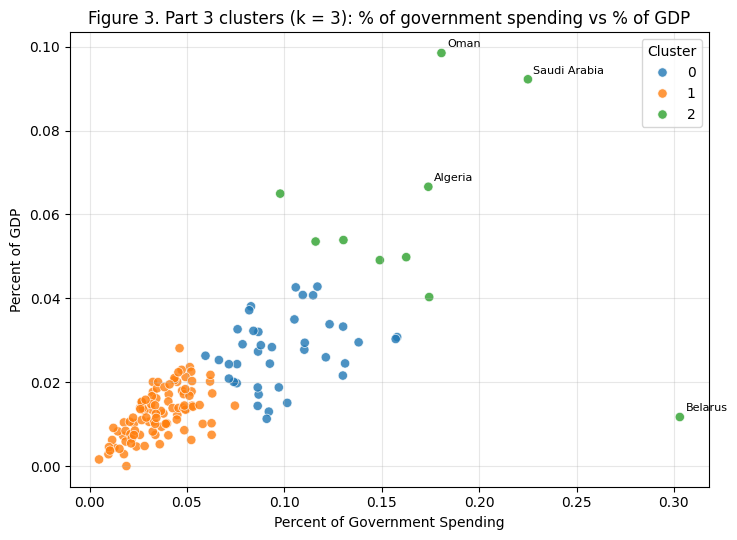

Table 7. Part 3 cluster profiles


n countries Percent of Government Spending               \
                                              mean median   std   
cluster                                                           
0                39                          0.099  0.092 0.024   
1                99                          0.036  0.034 0.015   
2                10                          0.171  0.168 0.059   

        Percent of GDP                   top 3 by Percent of GDP  
                  mean median   std                               
cluster                                                           
0                0.027  0.028 0.008      Morocco, Russia, Brunei  
1                0.013  0.013 0.006      Greece, Estonia, Poland  
2                0.058  0.054 0.025  Oman, Saudi Arabia, Algeria

Cluster 0 (39 countries): Bahrain, Bangladesh, Botswana, Brunei, Burkina Faso, Burundi, Cambodia, Central African Republic, Chad, Chile, Colombia, Congo, Republic, Ecuador, Equatorial Guinea, Gabon, Guinea, India, Iran, Iraq, Korea, South, Lebanon, Mali, Mauritania, Morocco, Myanmar, Namibia, Niger, Russia, Singapore, South Sudan, Sri Lanka, Sudan, Taiwan, Togo, Tunisia, Turkey, Uganda, Ukraine, United States of America

Cluster 1 (99 countries): Afghanistan, Albania, Angola, Argentina, Australia, Austria, Belgium, Belize, Benin, Bolivia, Bosnia and Herzegovina, Brazil, Bulgaria, Cameroon, Canada, Cape Verde, China, Congo, DR, Croatia, Cyprus, Czechia, Denmark, Dominican Republic, Egypt, El Salvador, Estonia, Ethiopia, Fiji, Finland, France, Gambia, The, Georgia, Germany, Ghana, Greece, Guatemala, Guinea-Bissau, Guyana, Haiti, Honduras, Hungary, Indonesia, Ireland, Italy, Jamaica, Japan, Kazakhstan, Kenya, Kosovo, Kyrgyz Republic, Latvia, Lesotho, Liberia, Lithuania, Luxembourg, Madaga

Part 3 cluster,0,1,2,All
Part 2 cluster,,,,
0,32,73,6,111
1,5,25,0,30
2,1,0,0,1
3,1,1,4,6
All,39,99,10,148


Table 9. Part 4 scree values


...

Table 10. Correlation matrix of all 4 variables


,Spending (2020 USD),Spending per Capita,Percent of Government Spending,Percent of GDP
Spending (2020 USD),1.000,0.451,0.055,0.144
Spending per Capita,0.451,1.000,0.197,0.503
Percent of Government Spending,0.055,0.197,1.000,0.729
Percent of GDP,0.144,0.503,0.729,1.000


Table 11. Part 4 cluster profiles


n countries Spending (2020 USD)                         \
                                   mean     median         std   
cluster                                                          
0                26          15,330.619  5,857.061  18,923.469   
1                30           9,073.544  1,663.090  18,135.033   
2                86           4,513.544    288.062  27,841.231   
3                 6         147,964.582 15,897.571 309,635.190   

        Spending per Capita                   Percent of Government Spending  \
                       mean    median     std                           mean   
cluster                                                                        
0                   612.678   579.005 241.190                          0.033   
1                   215.921   137.956 261.610                          0.124   
2                    70.291    34.846  81.691                          0.043   
3                 1,875.151 1,780.060 489.800                          0.135   

                     Percent of GDP               \
        median   std           mean median   std   
cluster                                            
0        0.032 0.012          0.017  0.015 0.006   
1        0.116 0.044          0.034  0.032 0.011   
2        0.040 0.022          0.012  0.013 0.006   
3        0.113 0.055          0.063  0.059 0.028   

                           top 3 by Spending per Capita  
                                                         
cluster                                                  
0                     Norway, Australia, United Kingdom  
1                         Brunei, Korea, South, Bahrain  
2                             Uruguay, Czechia, Hungary  
3        Israel, United States of America, Saudi Arabia

Cluster 0 (26 countries): Australia, Austria, Belgium, Canada, Cyprus, Denmark, Estonia, Finland, France, Germany, Greece, Italy, Japan, Latvia, Lithuania, Luxembourg, Netherlands, New Zealand, Norway, Poland, Portugal, Slovakia, Spain, Sweden, Switzerland, United Kingdom

Cluster 1 (30 countries): Algeria, Armenia, Azerbaijan, Bahrain, Belarus, Botswana, Brunei, Burkina Faso, Cambodia, Chad, Colombia, Congo, Republic, India, Iran, Iraq, Jordan, Korea, South, Lebanon, Mali, Mauritania, Morocco, Myanmar, Namibia, Pakistan, Russia, Taiwan, Togo, Tunisia, Uganda, Ukraine

Cluster 2 (86 countries): Afghanistan, Albania, Angola, Argentina, Bangladesh, Belize, Benin, Bolivia, Bosnia and Herzegovina, Brazil, Bulgaria, Burundi, Cameroon, Cape Verde, Central African Republic, Chile, China, Congo, DR, Croatia, Czechia, Dominican Republic, Ecuador, Egypt, El Salvador, Equatorial Guinea, Ethiopia, Fiji, Gabon, Gambia, The, Georgia, Ghana, Guatemala, Guinea, Guinea-Bissau, Guyana, Haiti, Honduras, 

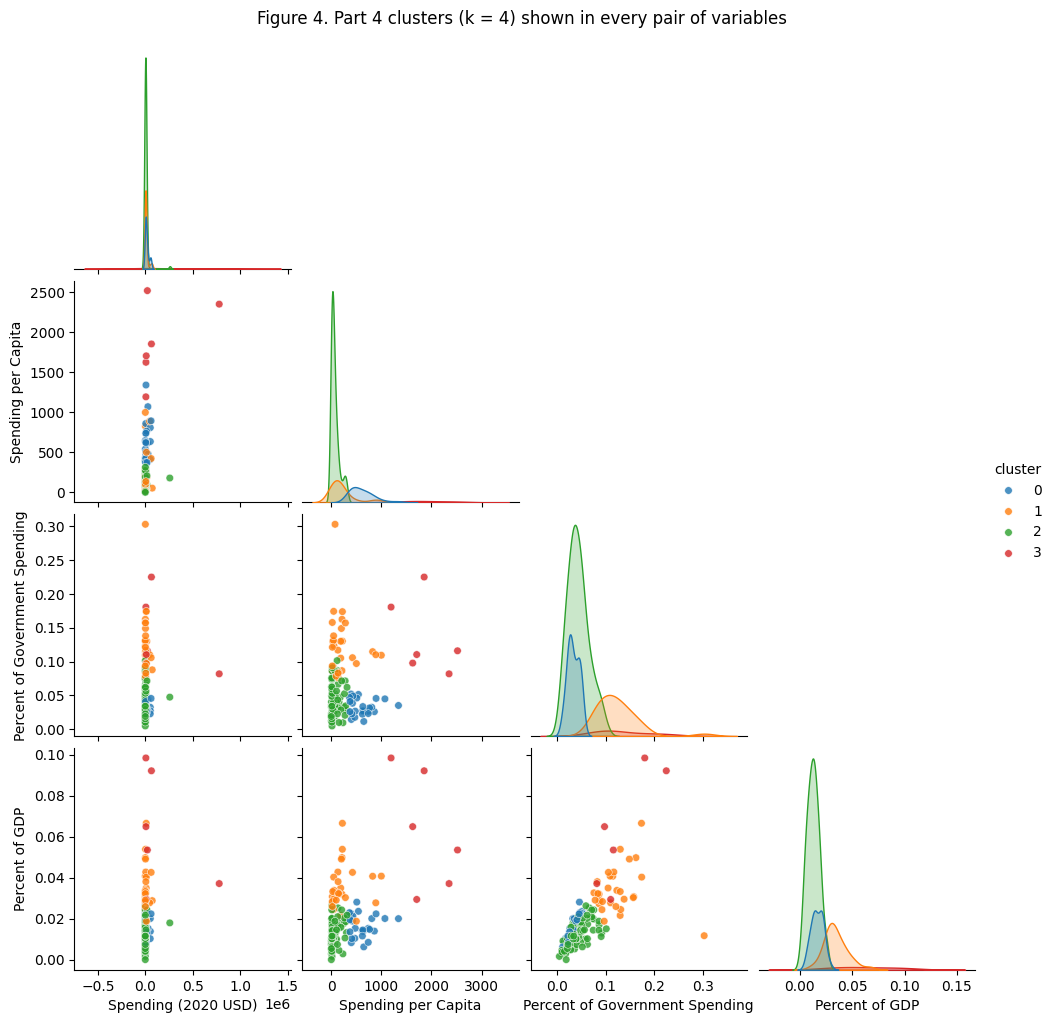

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from IPython.display import display
from google.colab import drive
drive.mount ('/content/drive')

pd.set_option('display.float_format', '{:,.3f}'.format)  # readable numbers in tables
pd.set_option('display.max_colwidth', 150)

df = pd.read_csv('/content/drive/MyDrive/SIPRI Military Expenditure Database.csv')

#1 cleaning
#filter by year (2020)
df_2020 = df.loc[df['Year'] == 2020]
dropped = df_2020.loc[df_2020.isna().any(axis=1), 'Country'].tolist()
df = df_2020.dropna().copy()

print(f"Rows in 2020: {len(df_2020)} | kept after dropna: {len(df)} | dropped: {len(dropped)}")
print("Dropped for missing data:", ', '.join(dropped) if dropped else 'none')

print("\nTable 1. Column types")
display(df.dtypes.to_frame('dtype'))

print("Table 2. Summary statistics, 2020 (one row per variable)")
display(df.describe().T)

#no further cleaning is necessary:
#the 4 money/ percent variables are already floats; country is okay as an object; year is irrelavant (only 2020)
#shape matches the 148 in the question

# [ADDED] dropna() removes any country missing even one value, and those countries are probably not
# [ADDED] random. SIPRI tends to lack reliable figures for closed states and countries in active
# [ADDED] conflict, so the 148 kept may underrepresent the highest-military-burden countries.
# [ADDED] The "dropped" list printed above shows which ones were excluded.
# [ADDED] 2020 is the COVID year. Many GDPs shrank and government budgets ballooned with relief spending,
# [ADDED] so "Percent of GDP" may be inflated and "Percent of Government Spending" deflated vs a typical year.
# [ADDED] SIPRI's USD figures use market exchange rates, not purchasing power parity. Countries with lower
# [ADDED] domestic costs (e.g., China, Russia, India) get more military per dollar than the figure suggests.


# ---------------------------------------------------------------
# Helper functions (same math as the original code)
# ---------------------------------------------------------------
def minmax(df, features):
    unscaled = df[features]
    return (unscaled - unscaled.min()) / (unscaled.max() - unscaled.min())

def scree(x, ks):
    return [KMeans(n_clusters=k, max_iter=300, n_init=10, random_state=100).fit(x).inertia_
            for k in ks]

def cluster_summary(df, features, col, rank_by):
    """n, mean/median/SD per feature, and the top 3 countries in each cluster."""
    g = df.groupby(col)
    out = g[features].agg(['mean', 'median', 'std'])
    out.insert(0, ('n countries', ''), g.size())
    out[(f'top 3 by {rank_by}', '')] = g[['Country', rank_by]].apply(
        lambda d: ', '.join(d.nlargest(3, rank_by)['Country']))
    out.index.name = 'cluster'
    return out

def print_members(df, col):
    for c, d in df.groupby(col):
        print(f"Cluster {c} ({len(d)} countries): {', '.join(sorted(d['Country']))}\n")

def cluster_scatter(ax, df, xcol, ycol, col, logx=False, n_label=3):
    """Scatter colored by cluster; labels the top countries on each axis."""
    d = df.assign(**{col: df[col].astype(str)})
    order = sorted(d[col].unique(), key=int)
    sns.scatterplot(data=d, x=xcol, y=ycol, hue=col, hue_order=order,
                    palette='tab10', s=45, alpha=0.8, ax=ax)
    to_label = pd.concat([d.nlargest(n_label, xcol),
                          d.nlargest(n_label, ycol)]).drop_duplicates('Country')
    for _, r in to_label.iterrows():
        ax.annotate(r['Country'], (r[xcol], r[ycol]), xytext=(4, 4),
                    textcoords='offset points', fontsize=8)
    if logx:
        ax.set_xscale('log' if (d[xcol] > 0).all() else 'symlog')
        ax.set_xlabel(f'{xcol} (log scale)')
    ax.legend(title='Cluster')
    ax.grid(alpha=0.3)


# ---------------------------------------------------------------
# Figure 1. Scree plots for parts 2-4 on one figure
# ---------------------------------------------------------------
ALL4 = ["Spending (2020 USD)", "Spending per Capita",
        "Percent of Government Spending", "Percent of GDP"]
feature_sets = {
    'Part 2: total & per capita': ALL4[:2],
    'Part 3: % gov & % GDP':      ALL4[2:],
    'Part 4: all 4 variables':    ALL4,
}
chosen_k = {'Part 2: total & per capita': 4,
            'Part 3: % gov & % GDP': 3,
            'Part 4: all 4 variables': 4}

ks = np.arange(1, 11)
sse_df = pd.DataFrame({name: scree(minmax(df, f), ks) for name, f in feature_sets.items()},
                      index=pd.Index(ks, name='k'))
sse_norm = sse_df / sse_df.iloc[0]          # SSE relative to k = 1
pct_drop = -sse_df.pct_change() * 100       # % reduction from k-1 to k

def scree_table(name):
    return pd.DataFrame({'SSE': sse_df[name], '% drop from k-1': pct_drop[name]})

colors = sns.color_palette('Set2', 3)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
for c, name in zip(colors, feature_sets):
    k = chosen_k[name]
    for ax, data in zip(axes, [sse_df, sse_norm]):
        ax.plot(ks, data[name], marker='o', color=c, label=f'{name}  (chosen k = {k})')
        ax.scatter(k, data.loc[k, name], s=220, facecolors='none', edgecolors=c, linewidths=2)
for ax in axes:
    ax.set_xticks(ks)
    ax.set_xlabel('Number of clusters (k)')
    ax.grid(alpha=0.3)
axes[0].set(title='Raw SSE (scale differs by feature set)', ylabel='Within-cluster SSE')
axes[1].set(title='Normalized SSE (relative to k = 1)', ylabel='SSE / SSE(k=1)')
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title='Feature set (circle = chosen k)', loc='lower center',
           ncol=3, bbox_to_anchor=(0.5, -0.12), frameon=False)
fig.suptitle('Figure 1. Scree plots, parts 2-4')
plt.tight_layout()
plt.show()

# [ADDED] Raw SSE is not comparable across parts. Part 4 has 4 features, so it has more dimensions
# [ADDED] contributing to the distances and a larger SSE automatically. The normalized panel is the
# [ADDED] fair comparison of elbow shape.


#2 minmax normalize
features = ALL4[:2]
x = minmax(df, features)

#scree plot
print("Table 3. Part 2 scree values")
display(scree_table('Part 2: total & per capita'))

#elbow at k =4

#scatterplot
model = KMeans(n_clusters=4, max_iter=300, n_init=10, random_state=100).fit(x)
df["cluster_p2"] = model.labels_

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cluster_scatter(axes[0], df, features[0], features[1], 'cluster_p2')
axes[0].set_title('Linear x-axis (the scale k-means sees)')
cluster_scatter(axes[1], df, features[0], features[1], 'cluster_p2', logx=True)
axes[1].set_title('Log x-axis (same clusters, non-US countries spread out)')
fig.suptitle('Figure 2. Part 2 clusters (k = 4): total spending vs spending per capita')
plt.tight_layout()
plt.show()

#describe table
print("Table 4. Part 2 cluster profiles")
display(cluster_summary(df, features, 'cluster_p2', rank_by='Spending per Capita'))

print_members(df, 'cluster_p2')

#there is a clear elbow (drop off in SSE)at k = 4
#the 4 clusters are mostly separated based on spending per capita, as seen in the scatterplot (no clear grouping across x except for US)
#the US is alone in cluster 2 (why the SD is NaN) and is by far the highest spender overall
# cluster 3 has 6 countries and the highest spending per capita
# cluster 0 has 111 countries and cluster 1 has 30 countries; both spend less per capita than the other two groups
#4/6 of cluster 3's countries are in the middle east

# [ADDED] Why the clusters run along the y-axis: total spending is extremely right-skewed. In 2020 the
# [ADDED] US spent roughly 3x the next-largest spender (China), so the US alone sets the max for
# [ADDED] min-max scaling. After scaling, nearly every other country has a total-spending value close
# [ADDED] to 0, so that feature barely affects distances and per capita does most of the work.
# [ADDED] The log-scale panel in Figure 2 shows how compressed the non-US countries are.
# [ADDED] K-means minimizes squared distances, so one extreme point can claim a cluster for itself.
# [ADDED] The US singleton is an outlier effect: effectively, only 3 clusters describe the other 147
# [ADDED] countries. The sharp elbow at k = 4 is likely partly due to isolating the US, which removes
# [ADDED] one very large squared distance.
# [ADDED] Spending per capita mixes two things: national wealth and how much a country prioritizes its
# [ADDED] military. GDP per capita isn't in the dataset, so "rich vs poor" is an inference here.
# [ADDED] The Middle East-heavy high-per-capita cluster fits small populations combined with high security
# [ADDED] spending (e.g., Gulf states, Israel), not just wealth.


#3 Repeat 2 with Percent of Government Spending and Percent of GDP
features = ALL4[2:]
x = minmax(df, features)

#scree
print("Table 5. Part 3 scree values")
display(scree_table('Part 3: % gov & % GDP'))

#elbow at k = 3 (very faint)

print("Table 6. Correlation between the two military-burden measures")
display(df[features].corr())

#scatterplot
model = KMeans(n_clusters=3, max_iter=300, n_init=10, random_state=100).fit(x)
df["cluster_p3"] = model.labels_

fig, ax = plt.subplots(figsize=(7.5, 5.5))
cluster_scatter(ax, df, features[0], features[1], 'cluster_p3')
ax.set_title('Figure 3. Part 3 clusters (k = 3): % of government spending vs % of GDP')
plt.tight_layout()
plt.show()

#describe table
print("Table 7. Part 3 cluster profiles")
display(cluster_summary(df, features, 'cluster_p3', rank_by='Percent of GDP'))

print_members(df, 'cluster_p3')

print("Table 8. How countries move between Part 2 and Part 3 clusters")
display(pd.crosstab(df['cluster_p2'], df['cluster_p3'],
                    rownames=['Part 2 cluster'], colnames=['Part 3 cluster'], margins=True))

#the elbow is much less sharp than in part 2
#US no longer in its own cluster (now in cluster 0); each cluster has multiple countries
#the clusters for part 2 were largely driven by the y; here is seems more even (x and y influence)
#It makes sense that more war torn countries (Isreal, Pakistan) are in the highest cluster

# [ADDED] The two burden measures are positively correlated (Table 6), since both measure military
# [ADDED] spending relative to the size of the economy or state. The points therefore form a diagonal
# [ADDED] band rather than separate blobs, and k-means slices the band into segments. That is why the
# [ADDED] elbow is faint: cluster boundaries are cut points along a continuum, not natural gaps.
# [ADDED] It's also why x and y appear to share influence. Along a diagonal band, both variables
# [ADDED] change together.
# [ADDED] The US drops into a lower cluster because its burden (about 3.7% of GDP in 2020) is high but
# [ADDED] not extreme. The world's largest budget looks fairly ordinary once scaled by economy size,
# [ADDED] which shows how much the choice of measure changes the story.
# [ADDED] High burden doesn't only mean active war. The top cluster also reflects long-running regional
# [ADDED] rivalries (e.g., Pakistan-India, Israel) and Gulf states with high security spending.
# [ADDED] Table 8 shows how Part 2 groupings get reshuffled under Part 3's variables.


#4: KMeans clustering with 4 numeric variables
features = ALL4
x = minmax(df, features)

#scree
print("Table 9. Part 4 scree values")
display(scree_table('Part 4: all 4 variables'))

#no clear elbow: SSE keeps dropping by similar amounts; set k = 4

print("Table 10. Correlation matrix of all 4 variables")
display(df[features].corr())

model = KMeans(n_clusters=4, max_iter=300, n_init=10, random_state=100).fit(x)
df["cluster_p4"] = model.labels_

#describe table
print("Table 11. Part 4 cluster profiles")
display(cluster_summary(df, features, 'cluster_p4', rank_by='Spending per Capita'))

print_members(df, 'cluster_p4')

order = sorted(df['cluster_p4'].unique())
g = sns.pairplot(df.assign(cluster=df['cluster_p4'].astype(str)), vars=features,
                 hue='cluster', hue_order=[str(c) for c in order], palette='tab10',
                 corner=True, plot_kws={'s': 30, 'alpha': 0.8})
g.fig.suptitle('Figure 4. Part 4 clusters (k = 4) shown in every pair of variables', y=1.02)
plt.show()

#the clusters combine both wealth/ spending per capital and the millitary spending of the country
#Unlike part 2, the US is not in its own group
#the 4 variables makes it difficult to see a true elbow, therefore selecting k is essentially arbitrary
#it appears the 4 groups are roughly: wealthy countries  + a lot of military spending, wealthy countries with little military spending,
#poor countries with a lot of military spending, poor countries with no military spending; this is a great simplification

# [ADDED] The 4 variables don't contribute equally. Total spending is still squashed near 0 for
# [ADDED] everyone but the US (see Part 2), so it adds little. The two burden measures are correlated
# [ADDED] (Table 10), so "burden" is effectively counted twice relative to per capita.
# [ADDED] The data therefore behaves roughly like 2 underlying dimensions: per-capita level and burden.
# [ADDED] That supports your 2x2 reading (high/low per capita x high/low burden) and is a reasonable
# [ADDED] justification for k = 4 even without a clear elbow.
# [ADDED] Every country in the dataset has some military spending; countries with no military aren't
# [ADDED] listed. "Low" is more accurate than "no" for the last group.
# [ADDED] Figure 4 is the only way to see 4-D clusters directly. Look for which panels show clean color
# [ADDED] separation; those are the variable pairs that drive the clustering.
# [ADDED] A silhouette score across k is a less subjective way to choose k when the elbow is unclear.


#5
#KMeans showed to be useful for groupings like poor vs rich in part 2 and high vs low military burden in part 3, but once you start introducing
#more than 2 variables (like in part 4), this approach becomes less useful, as the clustering becomes more difficult
#additionally, the clustering depends greatly on what variables are used
#additionally, throughout this anaylsis, it appears that most countries get grouped into a large lower cluster

# [ADDED] The large lower cluster is partly real, since most countries spend modestly. It is also an
# [ADDED] artifact of min-max scaling on right-skewed data: a few extreme countries set the range and
# [ADDED] compress everyone else near 0. Log-transforming the spending variables or standardizing
# [ADDED] (z-scores) would spread out that bulk and likely produce more balanced clusters.
# [ADDED] Results depend on variable choice and on scaling choice. The same data with different scaling
# [ADDED] could produce different clusters.
# [ADDED] More variables aren't inherently a problem. The difficulty in Part 4 comes from redundant
# [ADDED] (correlated) variables, an outlier-dominated feature, and losing the ability to view all
# [ADDED] dimensions in one plot.
# [ADDED] K-means works best on round, similarly sized clusters. This data is skewed with outliers and
# [ADDED] continuous bands rather than distinct groups, so the clusters are best read as descriptive cut
# [ADDED] points, not natural categories of countries

### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]

The AI was very effective in improving how the results were presented and interpreted. It fixed an indentation bug, merged the scree plots, added a legend, added a normalized SSE panel (made comparing elbow shapes more easy), and replaced the describe() table with a more detailed table (indicated the drop in SSE which was helpful). Also, instead of redundant code, the AI used helper functions to make the code more efficient which sigifigantly improved the readability of the code. Last, it added context to the original comments which make the information make more sense in the context of global politics.

Since the AI never got to see my original output or the data set, it could have potentially used incorrect or different outside information that influenced its comments in a way that the cvs did not express. I tried to limit this by verifying the comments and anaylsis against my code and google's results, but there is still the possibility of displaying incorrect information or hallucinations. This is my one remaining concern, but I am pretty confident that I verified all of the outside information and the AI generated anaylsis.